<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista-2-tomek2005/blob/main/UczenieMaszynowe_25_26_Lista2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza Zbiorów Danych
Laboratorium polega na analizie eksploracynej oraz wykonaniu redukcji wymiarowości dwóch zbiorów danych. W trakcie ćwiczenia zbadasz wskazane zbiory danych w następujących zadaniach:

1. Dla obu zbiorów danych:
    * Wczytaj zbiór danych. Opisz poszczególne kolumny - jakie zawierają atrybuty, co opisują. Zdecyduj czy któreś z kolumn należy przekształcić.
    * Zweryfikuj, czy w zbiorze występują wartości brakujące i/lub odstające. Zdecyduj jak (i czy) należy je usunąć.
    * Zbadaj korelacje między zmiennymi. Możesz posłużyć się macierzą korelacji.
    * Zwizualizuj najciekawsze/najważniejsze według Ciebie zależności w zbiorze.
2. Tylko dla zbioru Spotify Tracks:
    * Utwórz nową cechę "emocja" na podstawie dostępnych kolumn.
    * Dokonaj redukcji wymiarowości za pomocą metod *filter* oraz *wrapper*.
    * Zwizualizij zbiór za pomocą PCA oraz t-SNE. Sprawdź, jak na wizualizację wpływa normalizacja oraz standaryzacja danych.


## Zaliczenie laboratorium


 Za zadania można uzyskać maksymalnie 10 punktów według poniższej tabeli:

| ID | Zadanie | Zbiór danych | Ilość punktów |
|----|---------|--------------|---------------|
| 1  |Wczytanie zbioru danych. Określenie typów zmiennych. Opis kolumn. | Titanic, Spotify | 1 pkt |
| 2  |Filtracja danych. Usunięcie brakujących wartości. | Titanic, Spotify | 2 pkt|
| 3  |Analiza korelacji między zmiennymi (korzystając m. in. z macierzy korelacji) | Titanic, Spotify | 2 pkt |
| 4  |Przedstawienie wizualizacji (histogramów, pudełkowych) opisujących dane. | Titanic, Spotify | 2 pkt |
| 5  |Inżynieria i redukcja cech. | Spotify |1 pkt|
| 6 | Wizualizacja zbioru przy redukcji wymiarów poprzez PCA / t-SNE. Analiza wyników. | Spotify | 2 pkt. |

Analizę (punkty 1-4) należy przeprowadzić dla obu zbiorów. Redukcja (5-6) powinna zostać wykonana tylko dla zbioru *Spotify Tracks*.

### Pytania pomocnicze:
- Co decyduje o jakości i trudności zbioru danych? Czy któryś ze zbiorów z ćwiczenia jest łatwiejszy/trudniejszy? Dlaczego?
- Jakie informacje daje nam analiza pojedynczych cech w przeciwieństwie do analizy wielowymiarowej?
- Jakie własności zbioru mogą stanowić problem dla analizy?
- Na czym polega detekcja wartości odstających? Jaki wpływ na wyniki ma wybrana metoda?
- Jakie są wady/zalety metod radzenia sobie z brakującymi wartościami?
- Jak działa PCA i kiedy warto go stosować?
- Jak działa t-SNE i kiedy warto go stosować? Jaka jest fundamentalna różnica względem PCA?
- Na czym polega standaryzacja danych oraz normalizacja danych? Jakie są różnice
pomiędzy tymi metodami?

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Analiza zbioru danych [*Titanic*](https://www.kaggle.com/competitions/titanic/overview)

10 kwietnia 1912 roku brytyjski transatlantyk Titanic wypływa z Southampton, a 5 dni później schodzi na dno Atlantyku. Z 2208 osób na pokładzie, ocalało jedynie 704 [[1](https://pl.wikipedia.org/wiki/RMS_Titanic#Liczba_ofiar)]. Szanse przeżycia były silnie uzależnione od płci czy klasy podróży.

Zbiór danych Titanic zawiera informacje o 891 pasażerach statku. Podaje on między innymi płeć, klasę podróży, czy numer biletu. Celem tej części listy jest przeanalizowanie zbioru, opisanie wartości w nim występujących, i odpowiedź na pytanie: kto miał największe szanse na przeżycie Titanica?

## Opis danych

In [75]:
# wczytanie zbioru danych
titanic = pd.read_csv("titanic.csv")

titanic.shape

(891, 12)

In [76]:
# MIEJSCE NA TWÓJ KOD
print("HEAD: ")
print(titanic.head())

print("DESCRIBE: ")
print(titanic.describe())

print("INFO:")
print(titanic.info())


HEAD: 
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN       

In [77]:
print("Opis danych:")
print(f'PassengerId - identyfikator pasazera \n Survived - czy przezyl \n Pclass - klasa biletu \n Name - Imie pasaera \n Sex - plec \n Age - wiek \n SibSp - ilość rodzenstwa / małenstwa na pokładzie \n Parch - ilosc rodzicow na poladzie \n ticket - numer biletu \n fare - opłata za bilet \n Cabin - numer kabiny / mieszkanie \n Embarked - wejscie na pokład ')

Opis danych:
PassengerId - identyfikator pasazera 
 Survived - czy przezyl 
 Pclass - klasa biletu 
 Name - Imie pasaera 
 Sex - plec 
 Age - wiek 
 SibSp - ilość rodzenstwa / małenstwa na pokładzie 
 Parch - ilosc rodzicow na poladzie 
 ticket - numer biletu 
 fare - opłata za bilet 
 Cabin - numer kabiny / mieszkanie 
 Embarked - wejscie na pokład 


## Przekształcenie danych

Braki w danych:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


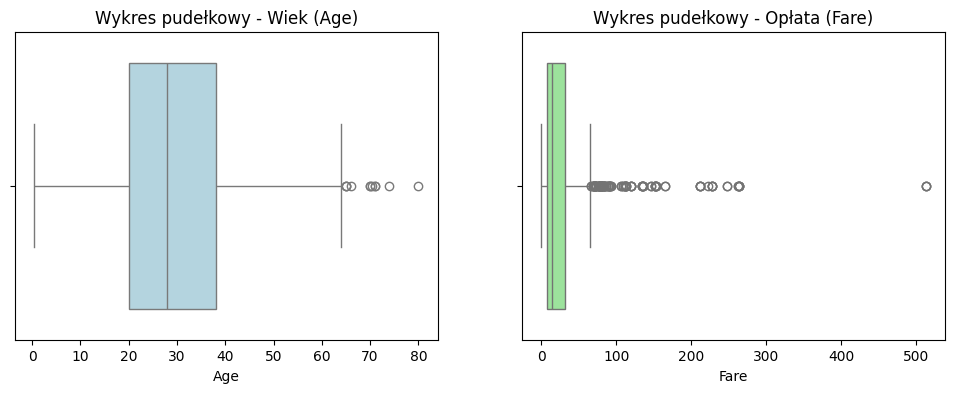

Poza wązami wartości skrajne - odstające to bilety luksusowe ktorych cena jest bardzo duza ale za to zwieksza sznase na pzerzycie
Natomiast w age tymi wartosciami sa osoby 80+ ktore sa realnymi osobami z mniejszymi szansami na pzezycie




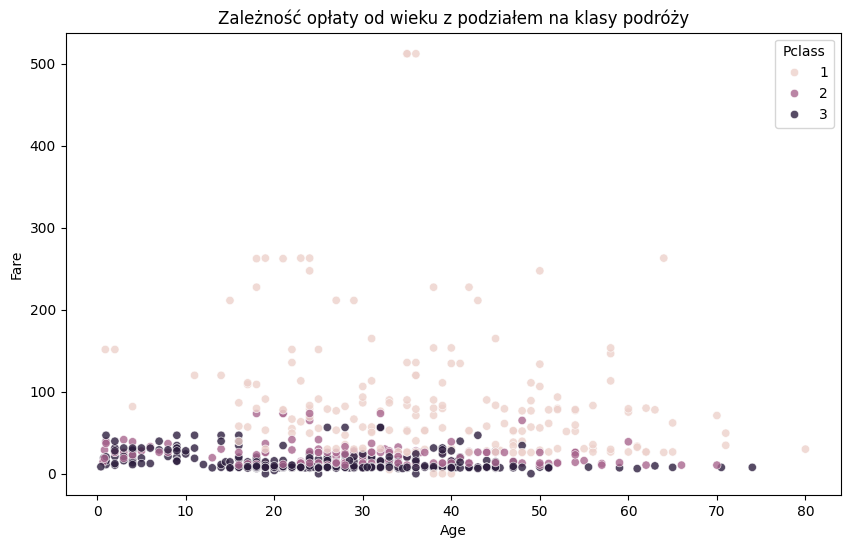

Z wykresu widac ze wartosc ceny biletu i klasy biletu jest bardzo silnie ze soba powiazana, im dorzszy bilet tym lepsza klasa
Widac rowniez ze wiekszosc biletow to te klasyu 2 i 3 tworzace gesta chmure na dole wykresu, rowniez widac ze drzsze bielty glownie kupowali ludzie w wieku srednim


In [78]:
# MIEJSCE NA TWÓJ KOD
print("Braki w danych:")
print(titanic.isnull().sum())


titanic = titanic.drop(columns=['PassengerId', 'Ticket'])


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=titanic, x='Age', ax=axes[0], color='lightblue')
axes[0].set_title('Wykres pudełkowy - Wiek (Age)')
sns.boxplot(data=titanic, x='Fare', ax=axes[1], color='lightgreen')
axes[1].set_title('Wykres pudełkowy - Opłata (Fare)')
plt.show()

print("Poza wązami wartości skrajne - odstające to bilety luksusowe ktorych cena jest bardzo duza ale za to zwieksza sznase na pzerzycie")
print("Natomiast w age tymi wartosciami sa osoby 80+ ktore sa realnymi osobami z mniejszymi szansami na pzezycie")
print()
print()



plt.figure(figsize=(10, 6))
sns.scatterplot(data=titanic, x='Age', y='Fare', hue='Pclass', alpha=0.8)
plt.title('Zależność opłaty od wieku z podziałem na klasy podróży')
plt.show()

print("Z wykresu widac ze wartosc ceny biletu i klasy biletu jest bardzo silnie ze soba powiazana, im dorzszy bilet tym lepsza klasa")
print("Widac rowniez ze wiekszosc biletow to te klasyu 2 i 3 tworzace gesta chmure na dole wykresu, rowniez widac ze drzsze bielty glownie kupowali ludzie w wieku srednim")

#wartosci odstajace
#jakis opis, analiy wielowymairow, wyswitalnei wartosci wzgledem innych



## Brakujące wartości

Wskazówki:
- Wartości ciągłe możemy zinterpolować korzystając z gotowej metody [`pandas.DataFrame.interpolate`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html)
- Wartości dyskretne można uzupełnić konkretną wartością używając metody [`pandas.DataFrame.fillna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)
- Aby lepiej ocenić czym uzupełnić NaNy, warto wyświetlić kolumnę na wykresie.
- W przypadku dyskretnych wartości, warto również znaleźć wartości unikatowe funkcją `unique()`.

### Wiek pasażera

In [79]:
# MIEJSCE NA TWÓJ KOD
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())

In [80]:
assert titanic['Age'].isnull().values.any() == False, "Kolumna 'wiek' zawiera brakujące wartości"


### Zaokrętowanie

In [81]:
# MIEJSCE NA TWÓJ KOD
most_common_port = titanic['Embarked'].mode()[0]
titanic['Embarked'] = titanic['Embarked'].fillna(most_common_port)

In [82]:
assert titanic['Embarked'].isnull().values.any() == False, "Kolumna 'zaokrętowanie' zawiera brakujące wartości"

### Kabina

In [83]:
# MIEJSCE NA TWÓJ KOD
titanic['Cabin'] = titanic['Cabin'].fillna('Unknown')

In [84]:
assert titanic['Cabin'].isnull().values.any() == False, "Kolumna 'kabina' zawiera brakujące wartości"

In [85]:
assert titanic.isnull().values.any() == False, "Zbiór danych zawiera brakujące wartości"

## Przedstawienie danych na wykresach

Wybierz 3-4 wykresy które przekazują według Ciebie najwięcej informacji.

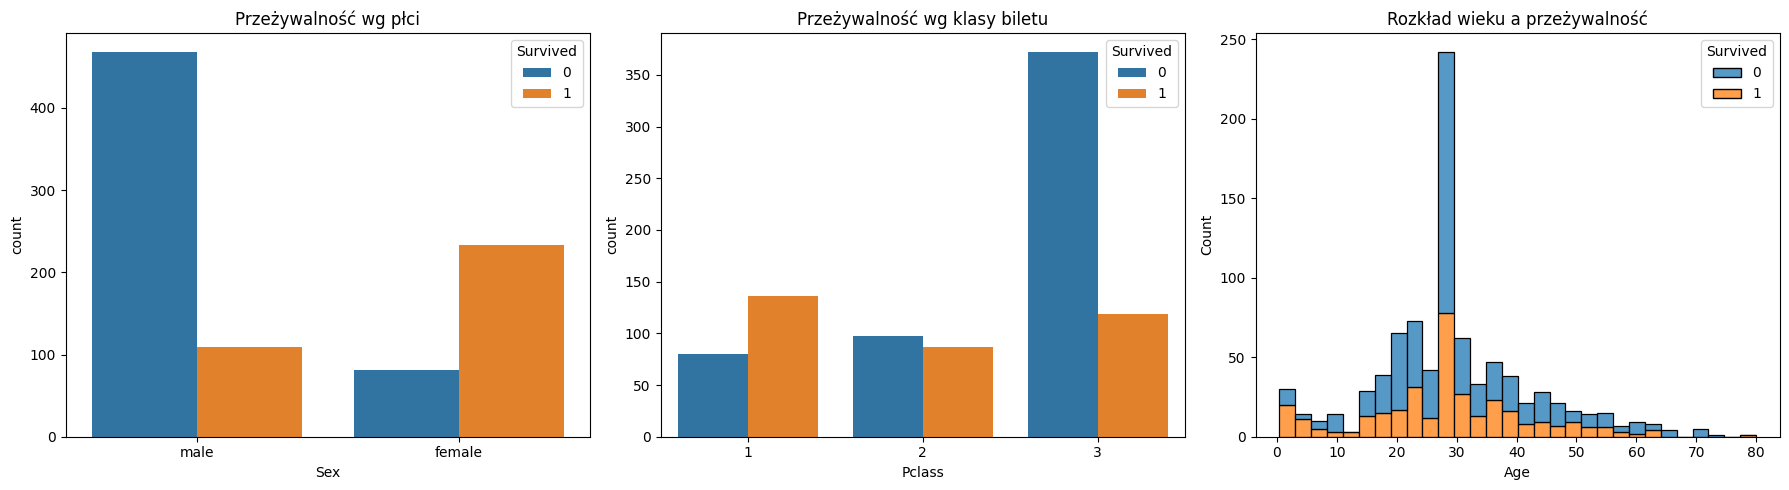

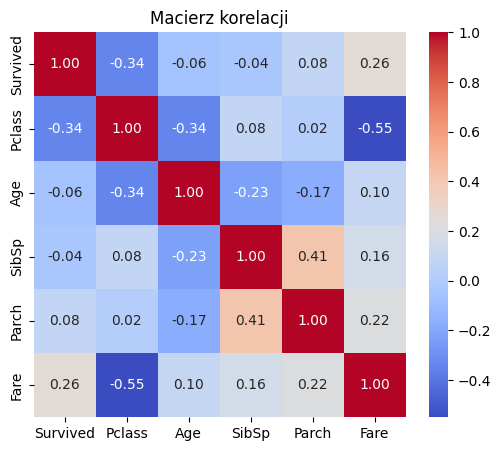

In [86]:
# MIEJSCE NA TWÓJ KOD
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Płeć a przeżywalność
sns.countplot(data=titanic, x='Sex', hue='Survived', ax=axes[0])
axes[0].set_title('Przeżywalność wg płci')

# Klasa a przeżywalność
sns.countplot(data=titanic, x='Pclass', hue='Survived', ax=axes[1])
axes[1].set_title('Przeżywalność wg klasy biletu')

# Wiek a przeżywalność (histogram)
sns.histplot(data=titanic, x='Age', hue='Survived', multiple="stack", ax=axes[2])
axes[2].set_title('Rozkład wieku a przeżywalność')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
number_col = titanic.select_dtypes(include=[np.number])
sns.heatmap(number_col.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Macierz korelacji')
plt.show()

## Podsumowanie - ocena przeżywalności

Na podstawie informacji uzyskanych podczas ćwiczenia - kto miał największe szanse przeżyć Titanica? Jaka cecha (bądź zestaw cech) decydowały o wyniku podróży?

In [87]:
# MIEJSCE NA TWÓJ KOD
print('Największe szanse na przeżycie miały kobiety podróżujące w 1. klasie. \nZ wykresów wyraźnie widać, że odsetek uratowanych kobiet był drastycznie wyższy niż mężczyzn. \nPonadto, klasa biletu Pclass mocno koreluje z przeżyciem, pasażerowie trzeciej klasy mieli najmniejsze szanse na ratunek.')

Największe szanse na przeżycie miały kobiety podróżujące w 1. klasie. 
Z wykresów wyraźnie widać, że odsetek uratowanych kobiet był drastycznie wyższy niż mężczyzn. 
Ponadto, klasa biletu Pclass mocno koreluje z przeżyciem, pasażerowie trzeciej klasy mieli najmniejsze szanse na ratunek.


# Analiza zbioru danych [*Spotify Tracks*](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

Celem tej części listy jest analiza dużego, rzeczywistego zbioru danych zawierającego informacje o ponad 100 tysiącach piosenek ze Spotify. Zbiór zawiera kilkanaście cech numerycznych opisujących utwór oraz cechy kategoryczne: wykonawcę, nazwę albumu, gatunek.

Analiza zbioru pozwoli w późniejszym etapie na skuteczną redukcję wymiarowości za pomocą dwóch metod: *filter* oraz *wrapper*. Końcowym celem listy jest przedstawienie wielowymiarowego zbioru na dwuwymiarowym wykresie za pomocą `PCA` oraz `tSNE`.

## Opis danych

In [90]:
spotify = pd.read_csv("spotify.csv")

spotify.shape

(59971, 21)

In [91]:
# MIEJSCE NA TWÓJ KOD

display(spotify.head())

print(spotify.info())

display(spotify.describe(include='all'))



,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.0,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4.0,acoustic


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59971 entries, 0 to 59970
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        59971 non-null  int64  
 1   track_id          59971 non-null  object 
 2   artists           59971 non-null  object 
 3   album_name        59971 non-null  object 
 4   track_name        59971 non-null  object 
 5   popularity        59971 non-null  int64  
 6   duration_ms       59971 non-null  int64  
 7   explicit          59971 non-null  bool   
 8   danceability      59971 non-null  float64
 9   energy            59971 non-null  float64
 10  key               59971 non-null  int64  
 11  loudness          59971 non-null  float64
 12  mode              59971 non-null  int64  
 13  speechiness       59971 non-null  float64
 14  acousticness      59971 non-null  float64
 15  instrumentalness  59971 non-null  float64
 16  liveness          59971 non-null  float6

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
count,59971.000000,59971,59971,59971,59971,59971.000000,5.997100e+04,59971,59971.000000,59971.000000,...,59971.000000,59971.000000,59971.000000,59971.000000,59971.000000,59971.000000,59971.00000,59971.000000,59970.000000,59970
unique,NaN,51482,18559,26803,42980,NaN,NaN,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60
top,NaN,0XDo1WmF8c70NuTZcMP2FH,George Jones,The Complete Hank Williams,Last Last,NaN,NaN,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,acoustic
freq,NaN,6,271,111,75,NaN,NaN,53726,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000
mean,29985.000000,NaN,NaN,NaN,NaN,32.526471,2.304434e+05,NaN,0.561872,0.658705,...,-8.135897,0.630238,0.092417,0.283254,0.186475,0.208736,0.44837,123.058683,3.910805,NaN
std,17312.280834,NaN,NaN,NaN,NaN,22.375109,1.163604e+05,NaN,0.176105,0.251528,...,4.960762,0.482744,0.125333,0.326911,0.328507,0.183116,0.25518,29.274467,0.412496,NaN
min,0.000000,NaN,NaN,NaN,NaN,0.000000,8.586000e+03,NaN,0.000000,0.000020,...,-42.044000,0.000000,0.000000,0.000000,0.000000,0.011200,0.00000,0.000000,0.000000,NaN
25%,14992.500000,NaN,NaN,NaN,NaN,15.000000,1.734795e+05,NaN,0.448000,0.491000,...,-9.876000,0.000000,0.036400,0.008245,0.000000,0.097100,0.23600,100.090500,4.000000,NaN
50%,29985.000000,NaN,NaN,NaN,NaN,32.000000,2.133060e+05,NaN,0.574000,0.706000,...,-6.835000,1.000000,0.050400,0.119000,0.000185,0.131000,0.42800,122.992000,4.000000,NaN
75%,44977.500000,NaN,NaN,NaN,NaN,50.000000,2.657665e+05,NaN,0.693000,0.872000,...,-4.918000,1.000000,0.090100,0.534000,0.181500,0.269000,0.64800,140.985000,4.000000,NaN


In [92]:
print("\nOPIS KOLUMN ZBIORU SPOTIFY")
opis = """
track_id: Unikalny identyfikator utworu w Spotify.
artists: Nazwa artysty / wykonawcy (lub kilku oddzielonych średnikiem).
album_name: Nazwa albumu.
track_name: Tytuł piosenki.
popularity: Wynik od 0 do 100 algorytmu Spotify oceniający popularność utworu.
duration_ms: Czas trwania utworu w milisekundach.
explicit: Czy utwór zawiera przekleństwa (True/False).
danceability: Taneczność (0.0 do 1.0) - na podstawie rytmu, tempa i siły bitu.
energy: Energia utworu (0.0 do 1.0) - szybkie, głośne i hałaśliwe utwory mają wyższą wartość.
key: Klucz muzyczny (0 = C, 1 = C# itd.). Wartość -1 oznacza brak wykrytego klucza.
loudness: Głośność w decybelach (dB).
mode: Skala durowa (Major = 1) lub molowa (Minor = 0).
speechiness: Udział słowa mówionego (bliżej 1.0 to podcasty, stand-upy lub rap).
acousticness: Poziom akustyczności (brak instrumentów elektronicznych/syntezatorów) od 0.0 do 1.0.
instrumentalness: Brak wokalu (bliżej 1.0 = utwór czysto instrumentalny).
liveness: Prawdopodobieństwo, że utwór był nagrany z udziałem publiczności na żywo (od 0.0 do 1.0).
valence: Pozytywność przekazu muzycznego (wysoka = wesoła, niska = smutna).
tempo: Tempo w uderzeniach na minutę (BPM).
time_signature: Metrum utworu (najczęściej 3/4 lub 4/4).
track_genre: Gatunek muzyczny przypisany do utworu.
"""
print(opis)


OPIS KOLUMN ZBIORU SPOTIFY

track_id: Unikalny identyfikator utworu w Spotify.
artists: Nazwa artysty / wykonawcy (lub kilku oddzielonych średnikiem).
album_name: Nazwa albumu.
track_name: Tytuł piosenki.
popularity: Wynik od 0 do 100 algorytmu Spotify oceniający popularność utworu.
duration_ms: Czas trwania utworu w milisekundach.
explicit: Czy utwór zawiera przekleństwa (True/False).
danceability: Taneczność (0.0 do 1.0) - na podstawie rytmu, tempa i siły bitu.
energy: Energia utworu (0.0 do 1.0) - szybkie, głośne i hałaśliwe utwory mają wyższą wartość.
key: Klucz muzyczny (0 = C, 1 = C# itd.). Wartość -1 oznacza brak wykrytego klucza.
loudness: Głośność w decybelach (dB).
mode: Skala durowa (Major = 1) lub molowa (Minor = 0).
speechiness: Udział słowa mówionego (bliżej 1.0 to podcasty, stand-upy lub rap).
acousticness: Poziom akustyczności (brak instrumentów elektronicznych/syntezatorów) od 0.0 do 1.0.
instrumentalness: Brak wokalu (bliżej 1.0 = utwór czysto instrumentalny).
livene

## Przekształcenia i filtracja danych

In [94]:
# MIEJSCE NA TWÓJ KOD
print("Braki w danych przed czyszczeniem:")
print(spotify.isnull().sum()[spotify.isnull().sum() > 0])

spotify = spotify.dropna()

poczatkowy_rozmiar = spotify.shape[0]
spotify = spotify.drop_duplicates()
koncowy_rozmiar = spotify.shape[0]

print(f"\nUsunięto {poczatkowy_rozmiar - koncowy_rozmiar} duplikatów.")
print(f"Kształt zbioru po czyszczeniu: {spotify.shape}")

Braki w danych przed czyszczeniem:
time_signature    1
track_genre       1
dtype: int64

Usunięto 0 duplikatów.
Kształt zbioru po czyszczeniu: (59970, 21)


## Wizualizacje

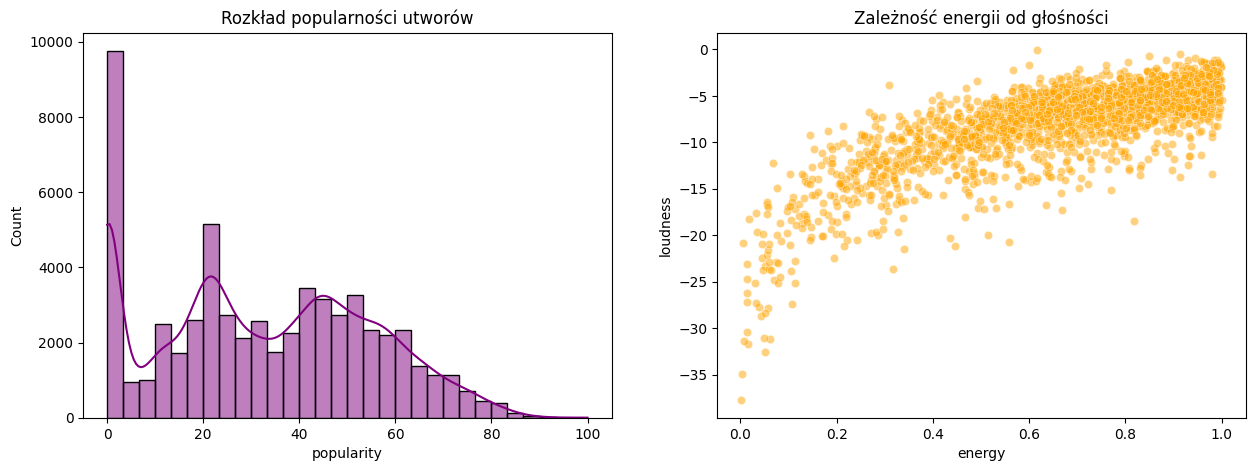

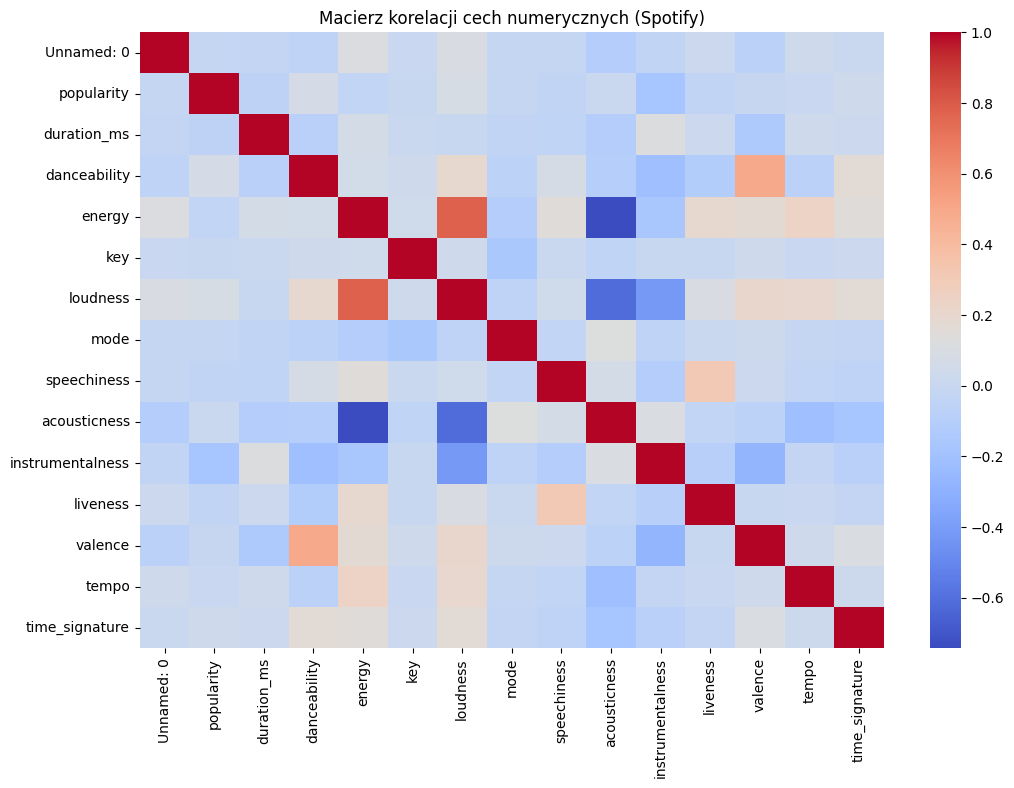

In [95]:
# MIEJSCE NA TWÓJ KOD
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# `popularnosc
sns.histplot(spotify['popularity'], bins=30, kde=True, color='purple', ax=axes[0])
axes[0].set_title('Rozkład popularności utworów')

# 2. Energia / glosnosc
sns.scatterplot(data=spotify.sample(2000, random_state=42), x='energy', y='loudness', alpha=0.5, color='orange', ax=axes[1])
axes[1].set_title('Zależność energii od głośności')
plt.show()

# Macierz koleracji
plt.figure(figsize=(12, 8))
num_cols = spotify.select_dtypes(include=[np.number])
sns.heatmap(num_cols.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Macierz korelacji cech numerycznych (Spotify)')
plt.show()

## Dodanie nowej cechy - emocja

Emocje w muzyce są przekazywane za pomocą akordów. W zbiorze mamy dostępne informacje nt. klucza i mody piosenki. Ich kombinacja będzie odpowiadać emocji, zgodnie z [tą rozpiską](https://ledgernote.com/blog/interesting/musical-key-characteristics-emotions/).

Moda w zbiorze jest określona jako 0 lub 1, co odpowiada *minor* i odpowiednio *major*.

Klucz jest w [notacji liczbowej](https://en.wikipedia.org/wiki/Pitch_class), czyli 0 odpowiada **C**, 1 odpowiada **C#**, itd.

Twoim zadaniem jest dodanie nowej kolumny "emotion" na podstawie dostępnych informacji.

In [96]:
# dla ułatwienia - gotowe słowniki

key_map = {0: 'C', 1: 'C#', 2: 'D', 3: 'D#', 4: 'E', 5: 'F', 6: 'F#', 7: 'G', 8: 'G#', 9: 'A', 10: 'A#', 11: 'B'}

emotion_map = {
    ('C', 'Major'):  'Happy',
    ('C#', 'Major'): 'Joyful',
    ('D', 'Major'):  'Triumphant',
    ('D#', 'Major'): 'Cruel',
    ('E', 'Major'):  'Noisy',
    ('F', 'Major'):  'Passionate',
    ('F#', 'Major'): 'Bright',
    ('G', 'Major'):  'Rustic',
    ('G#', 'Major'): 'Rich',
    ('A', 'Major'):  'Pastoral',
    ('A#', 'Major'): 'Magnificent',
    ('B', 'Major'):  'Harsh',

    ('C', 'Minor'):  'Sad',
    ('C#', 'Minor'): 'Melancholic',
    ('D', 'Minor'):  'Pensive',
    ('D#', 'Minor'): 'Anxious',
    ('E', 'Minor'):  'Grieving',
    ('F', 'Minor'):  'Tragic',
    ('F#', 'Minor'): 'Gloomy',
    ('G', 'Minor'):  'Serious',
    ('G#', 'Minor'): 'Mournful',
    ('A', 'Minor'):  'Tender',
    ('A#', 'Minor'): 'Dark',
    ('B', 'Minor'):  'Lonely',
}

In [97]:
# MIEJSCE NA TWÓJ KOD
def set_emotion(row):
    if row['key'] == -1:
        return 'Unknown'

    key = key_map.get(row['key'])
    scale = 'Major' if row['mode'] == 1 else 'Minor'

    return emotion_map.get((key, scale), 'Unknown')


spotify['emotion'] = spotify.apply(set_emotion, axis=1)

print("Przykładowe przypisane emocje:")
display(spotify[['track_name', 'key', 'mode', 'emotion']].head())

print("\nRozkład emocji w zbiorze:")
print(spotify['emotion'].value_counts())

Przykładowe przypisane emocje:


,track_name,key,mode,emotion
0,Comedy,1,0,Melancholic
1,Ghost - Acoustic,1,1,Joyful
2,To Begin Again,0,1,Happy
3,Can't Help Falling In Love,0,1,Happy
4,Hold On,2,1,Triumphant



Rozkład emocji w zbiorze:
emotion
Rustic         5266
Happy          5055
Triumphant     4763
Joyful         4141
Pastoral       3551
Rich           2868
Lonely         2832
Passionate     2607
Grieving       2546
Tender         2321
Bright         2304
Dark           2267
Noisy          2193
Harsh          2172
Tragic         2122
Gloomy         2113
Melancholic    1926
Magnificent    1774
Serious        1499
Sad            1434
Pensive        1306
Cruel          1101
Mournful       1093
Anxious         716
Name: count, dtype: int64


## Redukcja wymiarowości

W tej części zadania należy:
- zredukować wymiary zbioru poprzez usunięcie wybranych kolumn korzystając z metod *filter* i *wrapper*
- zwizualizować zbiór danych korzystając z metod redukcji wymiarowości
- zaimplementować standaryzację oraz normalizację
- przeanalizować jak te działania wpływają na wyniki redukcji



### Filter
Analizując pojedyncze kolumny, zdecyduj czy któreś z nich należy usunąć.

In [ ]:
# MIEJSCE NA TWÓJ KOD

### Wrapper
Korzystając z gotowej implementacji klasyfikatora las losowy, zdecyduj czy któreś z kolumn należy usunąć.

**UWAGA**

To jest bardzo uproszczona implementacja wrappera, która ma na celu jedynie pokazać jego działanie.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

def classify(df, features):
    """
    Dostępne cechy:
        'valence', 'year', 'acousticness', 'artists', 'danceability',
        'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key',
        'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date',
        'speechiness', 'tempo'
    """
    df = df.drop(columns=["Unnamed: 0", "track_id", "artists", "album_name", "track_name"], errors="ignore")
    df["explicit"] = df["explicit"].astype(int)
    df = df.sample(10000, random_state=42).dropna()

    df["popularity_bracket"] = pd.cut(df["popularity"], bins=[0, 33, 66, 100], labels=["low", "mid", "high"])
    df = df.dropna(subset=["popularity_bracket"])
    y = LabelEncoder().fit_transform(df["popularity_bracket"])
    X = df[features].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42))
    ])
    pipe.fit(X_train, y_train)

    acc  = pipe.score(X_test, y_test)

    print(f"Features  : {features}")
    print(f"Test Acc  : {acc:.4f}")
    return acc

In [ ]:
# WYWOŁAJ KLASYFIKATOR W TYM MIEJSCU
example_feats = ["duration_ms", "explicit", "danceability", "energy","key", "loudness", "mode", "speechiness", "acousticness","instrumentalness", "liveness", "valence", "tempo", "time_signature"]

base_acc = classify(spotify, example_feats)


### Wizualizacje (PCA i t-SNE)

W wizualizacji przetestuj kilka kolumn jako docelowe.

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn import preprocessing

In [ ]:
# przykładowe funkcje

def dataframe_xy(df):
    raise NotImplementedError()
    return X, y

# normalize to [0,1] range
def normalize(X):
    raise NotImplementedError()

# standarize (e.g, w/ scikit standard scaler)
def standarize(X):
    raise NotImplementedError()

# remove outliers
def remove_outliers(X, y):
    raise NotImplementedError()
